# Preliminaries

In [1]:
import eos
import numpy as np
import matplotlib.pyplot as plt

Load the response matrices.

In [2]:
R_mn_flat = np.load('./output/response_matrix_flat.npz')['arr_0']
R_mn_effonly = np.load('./output/response_matrix_effonly.npz')['arr_0']
R_mn = np.load('./output/response_matrix.npz')['arr_0']

Load the existing posterior-predictions at the truth level and create a series of "mock" posteriors ``FF-det``, ``FF-det-effonly``, and ``FF-det-flat`` that show the effect of the response matrix in the three varities discussed in the ``response_matrix.ipynb`` notebook.

In [3]:
predFF = eos.data.Prediction('./data/FF-only/pred-kperp')
samples = predFF.samples
weights = predFF.weights
observables = [None] * len(predFF.varied_parameters)
parameters = eos.Parameters()
for i, param in enumerate(predFF.varied_parameters):
    k = eos.Kinematics(**param['kinematics'])
    o = eos.Options(**param['options'])
    observables[i] = eos.Observable.make(param['name'], parameters, k, o)

samples_det_flat = (R_mn_flat @ samples.T).T
samples_det_effonly = (R_mn_effonly @ samples.T).T
samples_det = (R_mn @ samples.T).T

eos.data.Prediction.create('./data/FF-det-flat/pred-kperp', observables, samples_det_flat, weights)
eos.data.Prediction.create('./data/FF-det-effonly/pred-kperp', observables, samples_det_effonly, weights)
eos.data.Prediction.create('./data/FF-det/pred-kperp', observables, samples_det, weights)

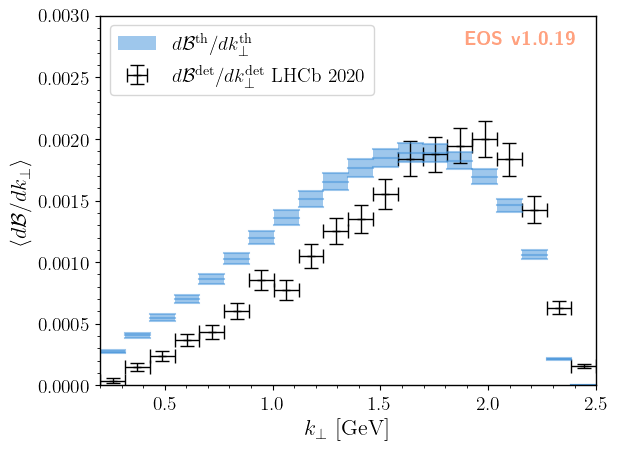

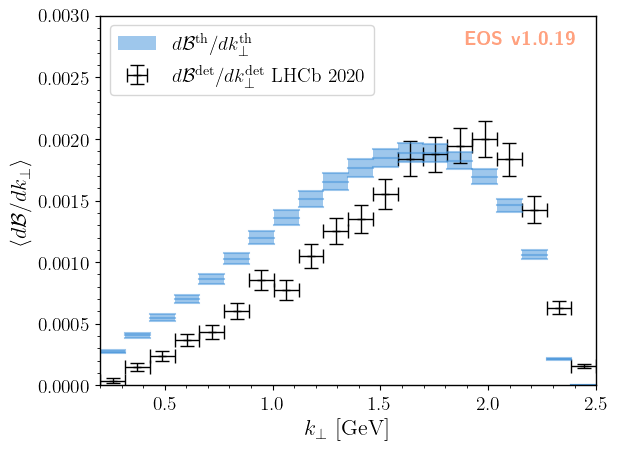

In [4]:
theory_vs_reconstructed_args = """
plot:
  xaxis:
    range: [0.2, 2.5]
    label: '$k_\\perp$ [GeV]'
  yaxis:
    range: [0, 3.0e-3]
    label: '$\\langle d\\mathcal{B}/dk_\\perp\\rangle$'
  items:
    - type: constraint
      color: 'black'
      label: '$d\\mathcal{B}^{\\mathrm{det}}/dk_\\perp^{\\mathrm{det}}$ LHCb 2020'
      constraints:
        - 'B_s^0->D_s^+mu^-nu::KinematicalDistribution[kperp]@LHCb:2020C'
      observable: 'B_s->D_slnu::BR(kperp_min,kperp_max)'
      variable: 'kperp'
    - type: uncertainty-binned
      color: 'eos:C0'
      label: '$d\\mathcal{B}^{\\mathrm{th}}/dk_\\perp^{\\mathrm{th}}$'
      variable: 'kperp'
      datafile: './data/FF-only/pred-kperp'
  legend:
    position: 'upper left'
"""
theory_vs_reconstructed = eos.figure.FigureFactory.from_yaml(theory_vs_reconstructed_args)
theory_vs_reconstructed.draw(output='./figures/theory-vs-reconstructed.pdf')
theory_vs_reconstructed = eos.figure.FigureFactory.from_yaml(theory_vs_reconstructed_args)
theory_vs_reconstructed.draw(output='./figures/theory-vs-reconstructed.png')

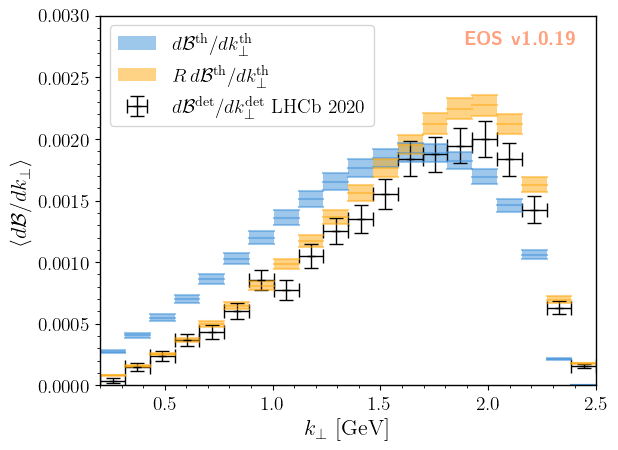

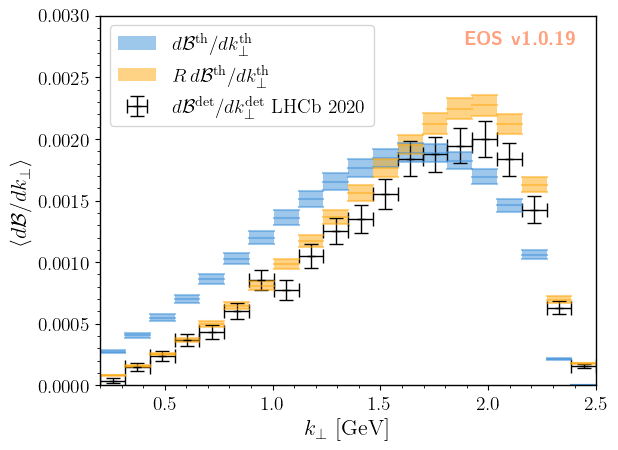

In [5]:
showcase_detector_effects_args = """
plot:
  xaxis:
    range: [0.2, 2.5]
    label: '$k_\\perp$ [GeV]'
  yaxis:
    range: [0, 3.0e-3]
    label: '$\\langle d\\mathcal{B}/dk_\\perp\\rangle$'
  items:
    - type: constraint
      color: 'black'
      label: '$d\\mathcal{B}^{\\mathrm{det}}/dk_\\perp^{\\mathrm{det}}$ LHCb 2020'
      constraints:
        - 'B_s^0->D_s^+mu^-nu::KinematicalDistribution[kperp]@LHCb:2020C'
      observable: 'B_s->D_slnu::BR(kperp_min,kperp_max)'
      variable: 'kperp'
    - type: uncertainty-binned
      color: 'eos:C0'
      label: '$d\\mathcal{B}^{\\mathrm{th}}/dk_\\perp^{\\mathrm{th}}$'
      variable: 'kperp'
      datafile: './data/FF-only/pred-kperp'
    - type: uncertainty-binned
      color: 'eos:C1'
      label: '$R \\, d\\mathcal{B}^{\\mathrm{th}}/dk_\\perp^{\\mathrm{th}}$'
      variable: 'kperp'
      datafile: './data/FF-det/pred-kperp'
  legend:
    position: 'upper left'
"""
showcase_detector_effects = eos.figure.FigureFactory.from_yaml(showcase_detector_effects_args)
showcase_detector_effects.draw(output='figures/showcase-detector-effects.pdf')
showcase_detector_effects = eos.figure.FigureFactory.from_yaml(showcase_detector_effects_args)
showcase_detector_effects.draw(output='figures/showcase-detector-effects.png')

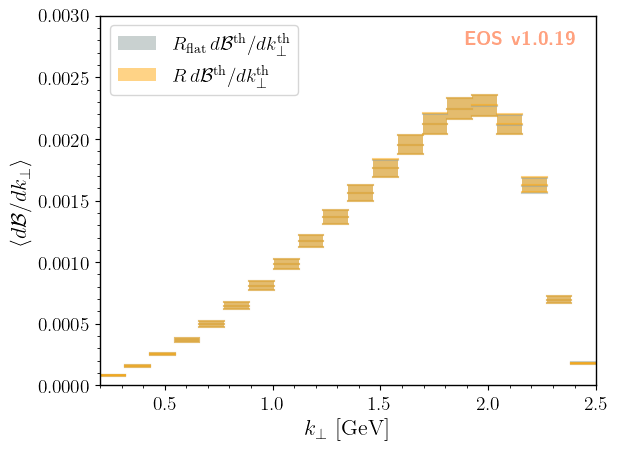

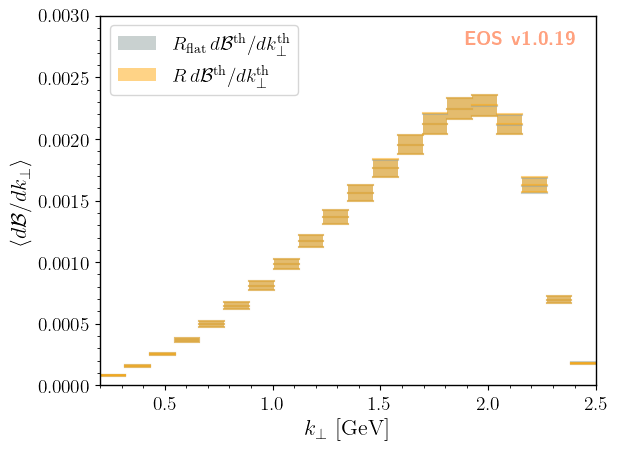

In [6]:
comparison_rmatrix_args = """
plot:
  xaxis:
    range: [0.2, 2.5]
    label: '$k_\\perp$ [GeV]'
  yaxis:
    range: [0, 3.0e-3]
    label: '$\\langle d\\mathcal{B}/dk_\\perp\\rangle$'
  items:
    - type: uncertainty-binned
      color: 'eos:C3'
      label: '$R_{\\mathrm{flat}} \\, d\\mathcal{B}^{\\mathrm{th}}/dk_\\perp^{\\mathrm{th}}$'
      variable: 'kperp'
      datafile: './data/FF-det-flat/pred-kperp'
    - type: uncertainty-binned
      color: 'eos:C1'
      label: '$R \\, d\\mathcal{B}^{\\mathrm{th}}/dk_\\perp^{\\mathrm{th}}$'
      variable: 'kperp'
      datafile: './data/FF-det/pred-kperp'
  legend:
    position: 'upper left'
"""
comparison_rmatrix = eos.figure.FigureFactory.from_yaml(comparison_rmatrix_args)
comparison_rmatrix.draw(output='figures/comparison-response-matrices.pdf')
comparison_rmatrix = eos.figure.FigureFactory.from_yaml(comparison_rmatrix_args)
comparison_rmatrix.draw(output='figures/comparison-response-matrices.png')

# Results of the $|V_{cb}|$ Fit

In [7]:
modeCKM = eos.data.Mode('./data/CKM/mode-default')
analysisCKM = eos.AnalysisFile('./analysis.yaml').analysis('CKM')
parametersCKM = analysisCKM.parameters
for param, value in zip(modeCKM.varied_parameters, modeCKM.mode):
    parametersCKM[param['name']].set(value)

Inserting custom observables ...
Inserted observable: B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015
Inserted observable: B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015
... finished inserting 2 custom observables
Task 'sample-nested' has a default value for argument 'sample', which can change across versions; consider providing a value explicitly
Task 'sample-nested' has a default value for argument 'maxiter', which can change across versions; consider providing a value explicitly
Task 'find-mode' has a default value for argument 'chain', which can change across versions; consider providing a value explicitly
Task 'find-mode' has a default value for argument 'mask_name', which can change across versions; consider providing a value explicitly
Task 'find-mode' has a default value for argument 'label', which can change across versions; consider providing a value explicitly
Task 'find-mode' has a default value for argument 'start_point', which can change across versions; consider providing a value expli

In [8]:
analysisCKM.goodness_of_fit()

In [9]:
samplesCKM = eos.data.ImportanceSamples('./data/CKM/samples')

In [10]:
Vcb_lower, Vcb_median, Vcb_upper = np.quantile(samplesCKM.samples[:, -1], [0.16, 0.5, 0.84], axis=0, weights=samplesCKM.weights, method='inverted_cdf')
print(f"Vcb = ({1000 * Vcb_median:.2f} + {1000 * (Vcb_upper - Vcb_median):.2} - {1000 * (Vcb_median - Vcb_lower):.2f}) \\times 10^(-3)")

Vcb = (38.65 + 0.81 - 0.80) \times 10^(-3)


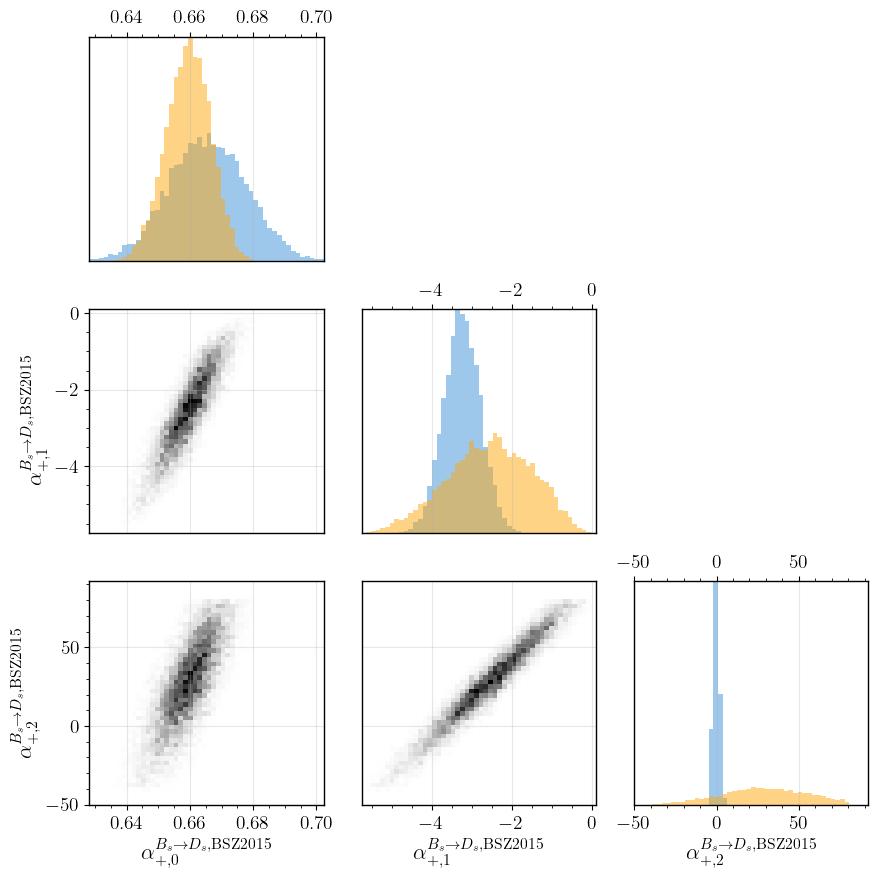

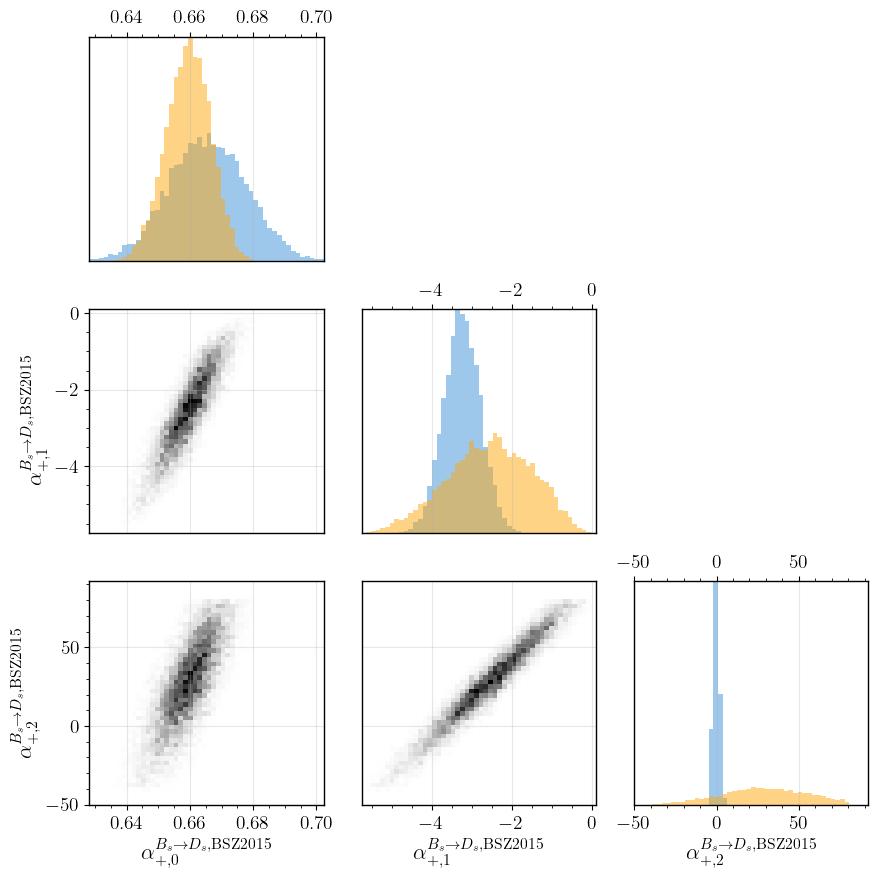

In [11]:
result_args = r"""
type: corner
variables:
  - 'B_s->D_s::alpha^f+_0@BSZ2015'
  - 'B_s->D_s::alpha^f+_1@BSZ2015'
  - 'B_s->D_s::alpha^f+_2@BSZ2015'
contents:
  - path: './data/FF-only/samples'
    label: 'prior'
    color: 'eos:C0'
  - path: './data/FF-shape-Projection/samples'
    label: 'projection'
    color: 'eos:C1'
"""
result_figure = eos.figure.FigureFactory.from_yaml(result_args)
result_figure.draw(output='./figures/ff-shape-current-vs-projection.pdf')
result_figure = eos.figure.FigureFactory.from_yaml(result_args)
result_figure.draw(output='./figures/ff-shape-current-vs-projection.png')

Computing KDE for samples of variable 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'


Computing KDE for samples of variables 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015' and 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variables 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015' and 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'
Computing KDE for samples of variables 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015' and 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variables 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015' and 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
Computing KDE for samples of variable 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'


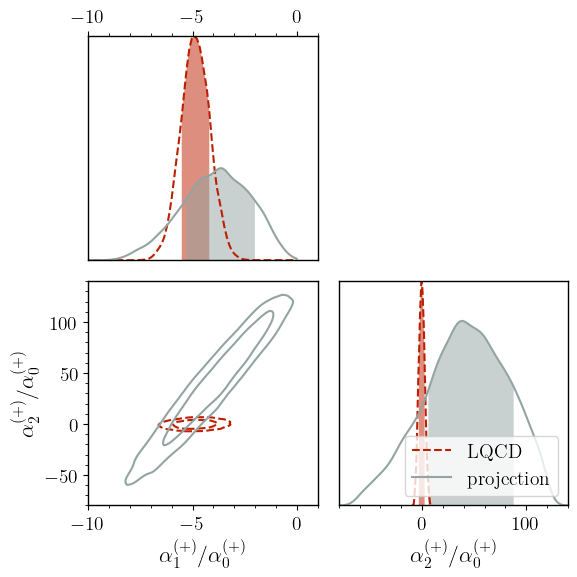

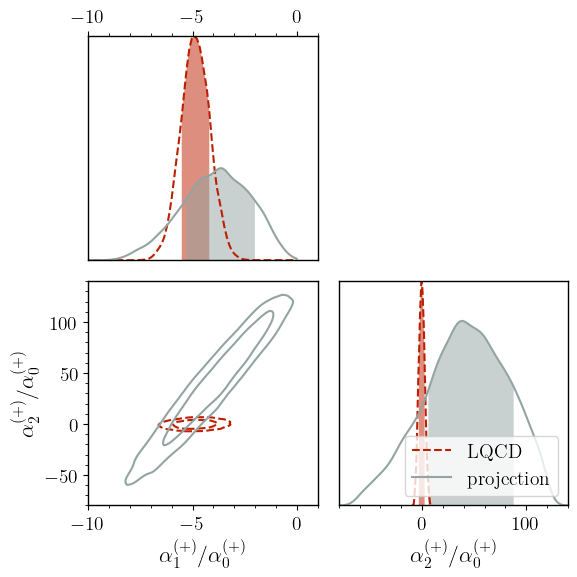

In [12]:
results_args = r"""
type: grid
shape: [2, 2]
plots:
  - xaxis:
      range: [-10.0, +1.0]
      ticks:
        position: 'top'
    yaxis:
      ticks:
        visible: false
    items:
      - type: kde1D
        datafile: './data/FF-only/pred-results'
        variable: 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'
        linestyle: 'dashed'
        color: 'eos:C2'
      - type: kde1D
        datafile: './data/FF-shape-Projection/pred-results'
        variable: 'B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015'
        color: 'eos:C3'
  - type: empty
  - xaxis:
      label: '$\alpha^{(+)}_1 / \alpha^{(+)}_0$'
      range: [-10.0, +1.0]
    yaxis:
      label: '$\alpha^{(+)}_2 / \alpha^{(+)}_0$'
      range: [-80.0, 140.0]
    items:
      - type: kde2D
        datafile: './data/FF-only/pred-results'
        variables: ['B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015', 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015']
        levels: [68, 95]
        linestyle: 'dashed'
        color: 'eos:C2'
        contours: ['lines']
      - type: kde2D
        datafile: './data/FF-shape-Projection/pred-results'
        variables: ['B_s->D_s::alpha^f+_1/alpha^f+_0@BSZ2015', 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015']
        levels: [68, 95]
        color: 'eos:C3'
        contours: ['lines']
  - xaxis:
      label: '$\alpha^{(+)}_2 / \alpha^{(+)}_0$'
      range: [-80.0, 140.0]
    yaxis:
      ticks:
        visible: false
    items:
      - type: kde1D
        datafile: './data/FF-only/pred-results'
        variable: 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
        color: 'eos:C2'
        linestyle: 'dashed'
        label: 'LQCD'
      - type: kde1D
        datafile: './data/FF-shape-Projection/pred-results'
        variable: 'B_s->D_s::alpha^f+_2/alpha^f+_0@BSZ2015'
        color: 'eos:C3'
        label: 'projection'
    legend:
      position: 'lower right'
"""
results_figure = eos.figure.FigureFactory.from_yaml(results_args)
results_figure.draw(output='figures/projection-results.pdf')
results_figure = eos.figure.FigureFactory.from_yaml(results_args)
results_figure.draw(output='figures/projection-results.png')